##### Dataset, Full: https://github.com/alexeygrigorev/clothing-dataset, Small: https://github.com/alexeygrigorev/clothing-dataset-small Links for stanford course: https://cs231n.github.io/

In [1]:
# mounting google drive and conecting to default folder
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/deeplearning_projects/

Mounted at /content/drive
/content/drive/MyDrive/deeplearning_projects


In [4]:
# importing tensorflow and keras
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

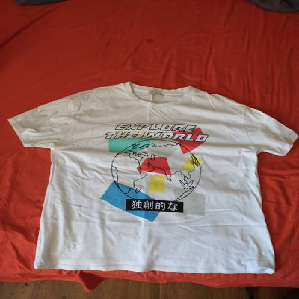

In [5]:
from tensorflow.keras.preprocessing.image import load_img
# loading an image
# path = '/workspaces/Machine-Learning-Zoomcamp/neuralNetworks/clothing-dataset-small-master/train/t-shirt/0a85a584-cb49-4795-b2f1-7eebbf09399a.jpg'
path_google = '/content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp/neuralNetworks/clothing-dataset-small-master/train/t-shirt/00003aeb-ace5-43bf-9a0c-dc31a03e9cd2.jpg'
img = load_img(path_google,target_size=(299,299))
img
#target size usuall (244,244) or (299,299) or (150,150)

In [6]:
x = np.array(img)
print("shape", x.shape)
print("dtype",x.dtype)

shape (299, 299, 3)
dtype uint8


In [7]:
print(img)
# img.shape = (244,244,3) / (height, width, channels) red, green, blue represents the channels
# Red, Green, Blue arrays with each unit measuring from 0 - 255
#(R,G,B) = (255,0,0) is red
#(R,G,B) = (0,255,0) is green
#(R,G,B) = (0,0,255) is blue
#(R,G,B) = (0,0,0) is black
#(R,G,B) = (255,255,255) is white


<PIL.Image.Image image mode=RGB size=299x299 at 0x7F45F053CBF0>


#### Pre-trained Concolutional Neural Network

In [8]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input, decode_predictions

In [9]:
model = Xception(weights ='imagenet', input_shape =(299,299,3)) # weights = 'imagenet' --> indicates model trained with imagenets

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
X = np.array([x])
X.shape # one image and each image the size is 299 by 299 with three channels for RGB

(1, 299, 299, 3)

In [11]:
# preprocessing of X
X = preprocess_input(X)


In [12]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step


In [13]:
pred.shape

(1, 1000)

In [14]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.8878356)),
  ('n03710637', 'maillot', np.float32(0.006834497)),
  ('n04456115', 'torch', np.float32(0.006463633)),
  ('n02730930', 'apron', np.float32(0.0059278402)),
  ('n04235860', 'sleeping_bag', np.float32(0.005427903))]]

**Convolutional Neural Networks**
applying filters across the image to produce a feature map. Each filter has a feature map. Higher values on the feature map indicates high similarity. The filters used by the suceeding layer (for example layer 2) is often based on combinations of filters used by the previous layer (layer one).

input image --> CNN ---> vector representation of image ---> dense layer --> final prediction

In [15]:
# sigmoid for multiple clases = softmax

**Transfer Learning:**  

In [16]:
# loading the data with ImageDataGenerator

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
# # 1. Create a local directory on the VM (outside of Drive)
!mkdir -p /content/dataset

# # 2. Copy the folder from your Drive to the local VM
# # Note: Use -r for folders. Ensure the path matches your Drive exactly.
!cp -r /content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp/neuralNetworks/clothing-dataset-small-master/* /content/dataset/


In [21]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [20]:
train_gen = ImageDataGenerator(preprocessing_function = preprocess_input)
train_ds = train_gen.flow_from_directory('/content/dataset/train', target_size =(150,150),  batch_size= 32)
# training on smaller dimensions enable the model train faster, batch_size represent no of units(images)


Found 3068 images belonging to 10 classes.


In [23]:
print("X.shape --->", X.shape)# 32 images, in he dimension of 150 by 150 with 3 channels
print("y.shape --->", y.shape) # 32 rows ad 10 columns means 32 images and values for the 10 classes for each image

X.shape ---> (32, 150, 150, 3)
y.shape ---> (32, 10)


In [22]:
X,y = next(train_ds)

In [24]:
y[:5] # multiclass classification.
'''
1 ----> t-shirt
2 ----> t-shirt
3 ----> pants
4 ----> longsleeve
'''

'\n1 ----> t-shirt\n2 ----> t-shirt\n3 ----> pants\n4 ----> longsleeve\n'

In [25]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [26]:
# val data
val_gen = ImageDataGenerator(preprocessing_function = preprocess_input)
val_ds = val_gen.flow_from_directory('/content/dataset/validation', target_size =(150,150),  batch_size= 32,shuffle=False)

Found 341 images belonging to 10 classes.


In [ ]:
# training the model

In [27]:
# base model = Xception
base_model = Xception(weights='imagenet', include_top = False, input_shape=(150,150,3))
#include_top = False ---> lets the model know that we would not need the dense layers and final layer.
# in keras top refers to the dense layers and the last layer while bottom refers to the convolutional layers
base_model.trainable = False # ----> this tells the model that we do not want to change convolutional layers

# create a new top
inputs = keras.Input(shape=(150,150,3))
base = base_model(inputs, training = False) # still have to indicate that training will not be done with the base mdoel
#pooling
vectors = keras.layers.GlobalAveragePooling2D()(base)
outputs = keras.layers.Dense(units=10)(vectors) # adding dense layers of 10 units
model = keras.Model(inputs,outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


In [29]:

# (32,5,5,2048) ---> dimension of preds without pooling
# shape is 4 dimensional
# 32 is size of batch,
# 5,5,2048 refers to dimension of each image
'''
pooling: refers to the process of changing the dimension  of an image or object  into a lower dimension.
In this particular case, we have to perform average pooling and change the 4 dimensional images into a 1d array.
This is done by taking slices of the 4d image and then assigning the average of each slice to a cell in the 1d array.
'''

# (32,2048) ----> dimension fo pred with pooling.
preds.shape

(32, 10)

In [30]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)
loss = keras.losses.CategoricalCrossentropy(from_logits=True) # for multiclass classification
# keras.losses.binary_crossentropy # for binary classification
# keras.losses.MeanSquaredError # for regression
model.compile(optimizer=optimizer,loss = loss, metrics=['accuracy'])


In [31]:
# import tensorflow as tf

# # 1. Load the dataset (replace 'path_to_your_data' with your actual Drive path)
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     '/content/drive/MyDrive/your_folder/train',
#     image_size=(150, 150), # Match your model's input size
#     batch_size=32
# )

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     '/content/drive/MyDrive/your_folder/validation',
#     image_size=(150, 150),
#     batch_size=32
# )

# # 2. NOW you can use .cache() and .prefetch()
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [32]:
history = model.fit(train_ds, epochs = 10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 412ms/step - accuracy: 0.6542 - loss: 1.2921 - val_accuracy: 0.7801 - val_loss: 0.9624
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8145 - loss: 0.6162 - val_accuracy: 0.7977 - val_loss: 0.7359
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8641 - loss: 0.4049 - val_accuracy: 0.7918 - val_loss: 0.7734
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9136 - loss: 0.2266 - val_accuracy: 0.7947 - val_loss: 0.8997
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9508 - loss: 0.1424 - val_accuracy: 0.7918 - val_loss: 0.8647
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9589 - loss: 0.1165 - val_accuracy: 0.7918 - val_loss: 0.9463
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9619 - loss: 0.1059 - val_accuracy: 0.8211 - val_loss: 0.8987
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9788 - loss: 0.0668 - val_accuracy: 0.8152 -

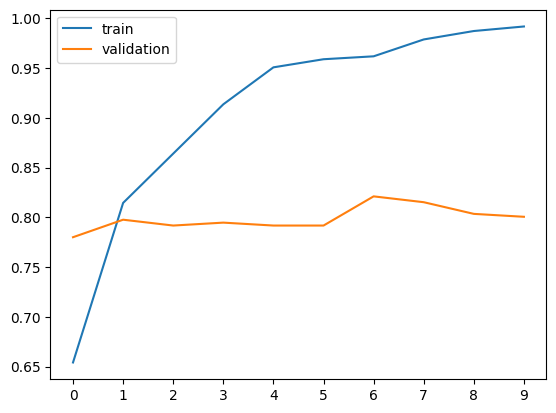

In [33]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'],label = 'validation')
plt.xticks(np.arange(10))
plt.legend()

# our network is overfitting

Adjusting the Learning rate.


In [34]:
'''
High ----> risk overfitting
medium ----> good
low  -----> risk underfitting
'''


'\nHigh ----> risk overfitting\nmedium ----> good\nlow  -----> risk underfitting\n'

In [35]:
def make_model(learning_rate =0.01):
  base_model = Xception(weights='imagenet', include_top = False, input_shape=(150,150,3))

  base_model.trainable = False
########################################################

  inputs = keras.Input(shape=(150,150,3))
  base = base_model(inputs, training = False)
  vectors = keras.layers.GlobalAveragePooling2D()(base)
  outputs = keras.layers.Dense(units=10)(vectors)
  model = keras.Model(inputs,outputs)
#######################################################################

  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)
  model.compile(optimizer=optimizer,loss = loss, metrics=['accuracy'])

  return model

In [36]:
scores = {}
for lr in [0.0001,0.001,0.01,0.1]:
  print(lr)
  model = make_model(lr)
  history = model.fit(train_ds, epochs = 10, validation_data=val_ds)
  scores[lr] = history.history
  print()
  print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 213ms/step - accuracy: 0.3286 - loss: 2.0194 - val_accuracy: 0.4633 - val_loss: 1.6639
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.5613 - loss: 1.4173 - val_accuracy: 0.6100 - val_loss: 1.2764
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.6415 - loss: 1.1550 - val_accuracy: 0.6833 - val_loss: 1.0841
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6926 - loss: 1.0060 - val_accuracy: 0.7126 - val_loss: 0.9649
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7197 - loss: 0.9099 - val_accuracy: 0.7331 - val_loss: 0.8917
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7379 - loss: 0.8399 - val_accuracy: 0.7595 - val_loss: 0.8323
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7520 - loss: 0.7854 - val_accuracy: 0.7713 - val_loss: 0.7918
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7669 - loss: 0.7427 - val_accuracy: 0

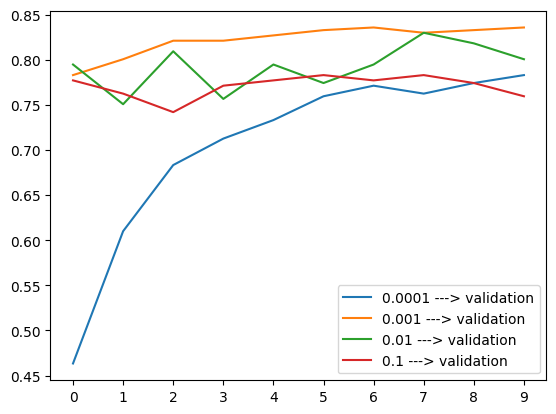

In [37]:
for lr,hist in scores.items():

  plt.plot(hist['val_accuracy'],label = f'{lr} ---> validation')
plt.xticks(np.arange(10))
plt.legend()


In [38]:
# learning rate of 0.001 is appears to be best
learning_rate = 0.001

**Checkpointing** : Saving the best model only
Training a model with callbacks

In [39]:
model.save_weights('/content/drive/MyDrive/deeplearning_projects/model_v1.weights.h5')


In [40]:
'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5'.format(epoch=12, val_accuracy=0.85)

'xception_v1_12_0.850.h5'

In [41]:
checkpoint = keras.callbacks.ModelCheckpoint('xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',save_best_only=True, monitor='val_accuracy', mode='max' )
# mode=max ---> maximizing accuracy since monitor is accuracy. If it were loss, then mode = min ----> to minimize loss
# note checkpoint is a list

In [42]:
learning_rate = 0.001 # as decided priviously
model = make_model(learning_rate=0.001)

history = model.fit(train_ds, epochs = 10, validation_data=val_ds, callbacks=[checkpoint])

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5041 - loss: 1.4820

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 237ms/step - accuracy: 0.6297 - loss: 1.1033 - val_accuracy: 0.7654 - val_loss: 0.7139
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7776 - loss: 0.6557

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7839 - loss: 0.6396 - val_accuracy: 0.8065 - val_loss: 0.6287
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8309 - loss: 0.5130

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.8347 - loss: 0.5090 - val_accuracy: 0.8211 - val_loss: 0.5723
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8634 - loss: 0.4322 - val_accuracy: 0.8152 - val_loss: 0.5604
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8885 - loss: 0.3701 - val_accuracy: 0.8182 - val_loss: 0.5451
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9021 - loss: 0.3281

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9019 - loss: 0.3289 - val_accuracy: 0.8358 - val_loss: 0.5215
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9205 - loss: 0.2891 - val_accuracy: 0.8299 - val_loss: 0.5322
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9335 - loss: 0.2588 - val_accuracy: 0.8328 - val_loss: 0.5045
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9439 - loss: 0.2348 - val_accuracy: 0.8328 - val_loss: 0.5241
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9589 - loss: 0.1958

96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.9531 - loss: 0.2092 - val_accuracy: 0.8446 - val_loss: 0.5259


**Adding more layers**

In [43]:
def make_model_arch (learning_rate =0.01, size_inner=100):
  base_model = Xception(weights='imagenet', include_top = False, input_shape=(150,150,3))

  base_model.trainable = False
########################################################

  inputs = keras.Input(shape=(150,150,3))
  base = base_model(inputs, training = False)
  vectors = keras.layers.GlobalAveragePooling2D()(base)

  inner = keras.layers.Dense(units= size_inner, activation='relu')(vectors) # adding an extra layer of 100 units

  outputs = keras.layers.Dense(units=10)(inner)
  model = keras.Model(inputs,outputs)
#######################################################################

  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)
  model.compile(optimizer=optimizer,loss = loss, metrics=['accuracy'])

  return model

In [44]:
scores = {}
for size in [10,100,1000]:
  print(size)
  model = make_model_arch(learning_rate=0.001,size_inner=size)
  history = model.fit(train_ds, epochs = 10, validation_data=val_ds)
  scores[size] = history.history
  print()
  print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 226ms/step - accuracy: 0.3263 - loss: 1.7667 - val_accuracy: 0.3988 - val_loss: 1.4590
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5955 - loss: 1.1814 - val_accuracy: 0.7390 - val_loss: 0.9078
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7334 - loss: 0.8310 - val_accuracy: 0.7801 - val_loss: 0.7530
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7741 - loss: 0.6753 - val_accuracy: 0.7830 - val_loss: 0.6725
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8041 - loss: 0.5847 - val_accuracy: 0.7713 - val_loss: 0.6706
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8250 - loss: 0.5195 - val_accuracy: 0.7918 - val_loss: 0.6343
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8465 - loss: 0.4688 - val_accuracy: 0.7918 - val_loss: 0.6503
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8634 - loss: 0.4262 - val_accuracy: 0.777

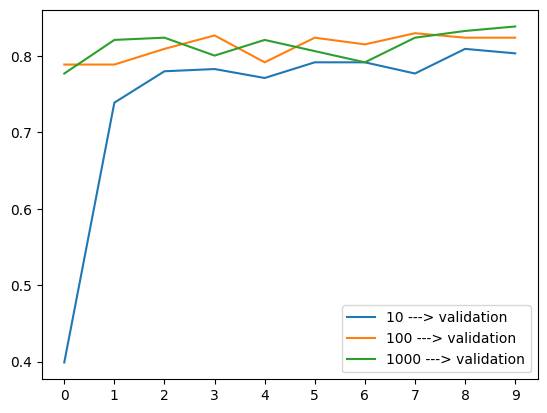

In [45]:
for size,hist in scores.items():

  plt.plot(hist['val_accuracy'],label = f'{size} ---> validation')
plt.xticks(np.arange(10))
plt.legend()


Regularization and Dropout

dropout - randomly hide a part of the input. A part of cel of a layer gets frozen and is not updated.  Different parts of the network is frozen during different epochs.

In [46]:
def make_model_arch_v3 (learning_rate =0.01, size_inner=100,drop_rate=0.5):
  base_model = Xception(weights='imagenet', include_top = False, input_shape=(150,150,3))

  base_model.trainable = False
########################################################

  inputs = keras.Input(shape=(150,150,3))
  base = base_model(inputs, training = False)
  vectors = keras.layers.GlobalAveragePooling2D()(base)

  inner = keras.layers.Dense(units= size_inner, activation='relu')(vectors) #
  drop = keras.layers.Dropout(drop_rate)(inner) # drop_rate = 0.2 meaning 20%, 20@ of the network wil be
  #dropout applied to the inner layer

  outputs = keras.layers.Dense(units=10)(drop)
  model = keras.Model(inputs,outputs)
#######################################################################

  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)
  model.compile(optimizer=optimizer,loss = loss, metrics=['accuracy'])

  return model

In [47]:
scores = {}
for droprate in [0.0,0.2,0.5,0.8]:
  print(droprate)
  model = make_model_arch_v3(learning_rate=0.001,size_inner=100,drop_rate= droprate)
  history = model.fit(train_ds, epochs = 30, validation_data=val_ds)
  # increasing epochs to give neural network enough time to learn since adding dropout affects the rate at which the model learns
  scores[droprate] = history.history
  print()
  print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 222ms/step - accuracy: 0.6653 - loss: 0.9998 - val_accuracy: 0.7977 - val_loss: 0.6264
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.8204 - loss: 0.5225 - val_accuracy: 0.7977 - val_loss: 0.5917
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8797 - loss: 0.3572 - val_accuracy: 0.8065 - val_loss: 0.5649
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9231 - loss: 0.2586 - val_accuracy: 0.8299 - val_loss: 0.5374
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9495 - loss: 0.1862 - val_accuracy: 0.8270 - val_loss: 0.5756
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9668 - loss: 0.1345 - val_accuracy: 0.8094 - val_loss: 0.6131
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9834 - loss: 0.0980 - val_accuracy: 0.8358 - val_loss: 0.6096
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9941 - loss: 0.0651 - val_accuracy: 0.

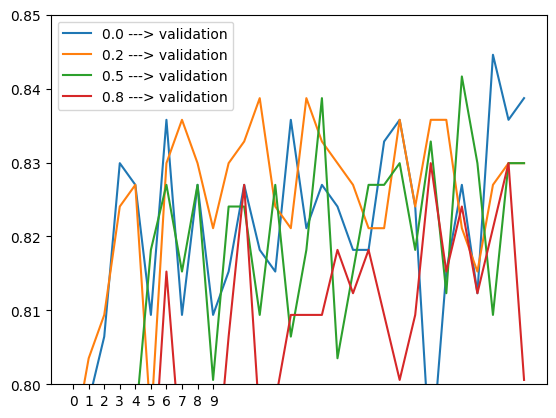

In [48]:
for droprate,hist in scores.items():

  plt.plot(hist['val_accuracy'],label = f'{droprate} ---> validation')
plt.ylim(0.80,0.85)
plt.xticks(np.arange(10))
plt.legend()

**Data Augmentation: creating more data from existing data.**

In [49]:
# techniques
# shear
# shift
# flip
# zoom x
# zoom y
# brightness/ contrast
# black patch

# train_gen_aug = ImageDataGenerator(preprocessing_function = preprocess_input,
#                                    rotation_range=20,
#                                    width_shift_range=0.2,   height_shift_range=0.2,
#                                    shear_range =10,
#                                    zoom_range=0.0,
#                                    vertical_flip = True,
#                                    zoom_range=0.2)

# import albumentations as A

# transform = A.Compose([
#     A.HorizontalFlip(p=0.5),
#     A.RandomBrightnessContrast(p=0.2),
#     A.Rotate(limit=30),
#     A.GaussianBlur(p=0.1),
# ])

# augmented = transform(image=image)["image"]

In [50]:
# augmentation with image gen
train_gen_aug = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   shear_range =10.0,
                                   zoom_range=0.1,
                                   vertical_flip = True)
train_ds_aug = train_gen.flow_from_directory('/content/dataset/train', target_size =(150,150),  batch_size= 32)
# we apply augmentation only to our training dataset
# we still need to be able to compare out model with the rest models that were not trained with augmented data.
val_gen = ImageDataGenerator(preprocessing_function = preprocess_input)
val_ds = val_gen.flow_from_directory('/content/dataset/validation', target_size =(150,150),  batch_size= 32,shuffle=False)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


**choosing Augmentations**
* Use your own judgement
* look at the dataset and see what kind of variations are there.
* Are objects always centered?
* Tune augmentation like a hyperparameter and see which works best.
* train with augmentation for 10 to 20 epochs to see if augmentation increases metrics.

In [51]:
droprate=0.2

model = make_model_arch_v3(learning_rate=0.001,size_inner=100,drop_rate= droprate)
history = model.fit(train_ds_aug, epochs = 50, validation_data=val_ds)
# increasing epochs to give neural network enough time to learn since adding dropout affects the rate at which the model learns
# training with augmented data and dropout requires more epochs for the model to learn all the neccessary realtionships

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.6483 - loss: 1.0467 - val_accuracy: 0.7771 - val_loss: 0.7206
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7767 - loss: 0.6193 - val_accuracy: 0.7977 - val_loss: 0.6397
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8331 - loss: 0.4702 - val_accuracy: 0.7918 - val_loss: 0.5747
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8778 - loss: 0.3430 - val_accuracy: 0.8094 - val_loss: 0.5556
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9078 - loss: 0.2738 - val_accuracy: 0.8328 - val_loss: 0.5491
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9260 - loss: 0.2270 - val_accuracy: 0.8182 - val_loss: 0.5619
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9540 - loss: 0.1648 - val_accuracy: 0.8358 - val_loss: 0.5463
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9628 - loss: 0.1339 - val_accuracy: 0.8182 -

Training a Large Model

In [52]:
# training a 299 x 2999 mode
train_gen_299 = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   shear_range = 10,
                                   zoom_range=0.1,
                                   horizontal_flip = True)
train_ds_299 = train_gen.flow_from_directory('/content/dataset/train', target_size =(299,299),  batch_size= 32)

val_gen_299 = ImageDataGenerator(preprocessing_function = preprocess_input)
val_ds_299 = val_gen.flow_from_directory('/content/dataset/validation', target_size =(299,299),  batch_size= 32,shuffle=False)

checkpoint = keras.callbacks.ModelCheckpoint('xception_v4_{epoch:02d}_{val_accuracy:.3f}.h5',save_best_only=True, monitor='val_accuracy', mode='max' )

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [53]:
def make_model_arch_v4 (input_size = 150, learning_rate =0.01, size_inner=100,drop_rate=0.5):
  base_model = Xception(weights='imagenet', include_top = False, input_shape=(input_size,input_size,3))

  base_model.trainable = False
########################################################

  inputs = keras.Input(shape=(input_size,input_size,3))
  base = base_model(inputs, training = False)
  vectors = keras.layers.GlobalAveragePooling2D()(base)

  inner = keras.layers.Dense(units= size_inner, activation='relu')(vectors) #
  drop = keras.layers.Dropout(drop_rate)(inner) # drop_rate = 0.2 meaning 20%, 20@ of the network wil be
  #dropout applied to the inner layer

  outputs = keras.layers.Dense(units=10)(drop)
  model = keras.Model(inputs,outputs)
#######################################################################

  optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
  loss = keras.losses.CategoricalCrossentropy(from_logits=True)
  model.compile(optimizer=optimizer,loss = loss, metrics=['accuracy'])

  return model

In [54]:
droprate=0.2

model = make_model_arch_v4(input_size = 299,learning_rate=0.001,size_inner=100,drop_rate= droprate)
history = model.fit(train_ds_299, epochs = 50, validation_data=val_ds_299,callbacks=[checkpoint])

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.6230 - loss: 1.1502

96/96 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7451 - loss: 0.7741 - val_accuracy: 0.8299 - val_loss: 0.5178
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8542 - loss: 0.4303

96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 276ms/step - accuracy: 0.8579 - loss: 0.4109 - val_accuracy: 0.8504 - val_loss: 0.4476
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.8865 - loss: 0.3419

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 265ms/step - accuracy: 0.8898 - loss: 0.3213 - val_accuracy: 0.8739 - val_loss: 0.3903
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 257ms/step - accuracy: 0.9100 - loss: 0.2711 - val_accuracy: 0.8680 - val_loss: 0.3893
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9068 - loss: 0.2532 - val_accuracy: 0.8739 - val_loss: 0.3783
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9270 - loss: 0.2195 - val_accuracy: 0.8680 - val_loss: 0.4126
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 259ms/step - accuracy: 0.9348 - loss: 0.1823 - val_accuracy: 0.8739 - val_loss: 0.3917
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9418 - loss: 0.1703

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 266ms/step - accuracy: 0.9423 - loss: 0.1679 - val_accuracy: 0.8798 - val_loss: 0.3686
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9619 - loss: 0.1289

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 269ms/step - accuracy: 0.9547 - loss: 0.1429 - val_accuracy: 0.8827 - val_loss: 0.3655
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step - accuracy: 0.9628 - loss: 0.1211 - val_accuracy: 0.8768 - val_loss: 0.3948
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9677 - loss: 0.1052 - val_accuracy: 0.8798 - val_loss: 0.3937
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9716 - loss: 0.0980 - val_accuracy: 0.8563 - val_loss: 0.4560
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.9720 - loss: 0.0966 - val_accuracy: 0.8827 - val_loss: 0.4083
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9772 - loss: 0.0844 - val_accuracy: 0.8768 - val_loss: 0.4051
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.9791 - loss: 0.0753 - val_accuracy: 0.8827 - val_loss: 0.4166
Epoch 16/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.9860 - loss: 0.0601 - val_accuracy

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.9925 - loss: 0.0346 - val_accuracy: 0.8886 - val_loss: 0.4568
Epoch 22/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9938 - loss: 0.0327 - val_accuracy: 0.8827 - val_loss: 0.5154
Epoch 23/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.9948 - loss: 0.0285 - val_accuracy: 0.8798 - val_loss: 0.4952
Epoch 24/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.9935 - loss: 0.0317 - val_accuracy: 0.8886 - val_loss: 0.4809
Epoch 25/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9962 - loss: 0.0273

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 268ms/step - accuracy: 0.9948 - loss: 0.0266 - val_accuracy: 0.9032 - val_loss: 0.4785
Epoch 26/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - accuracy: 0.9961 - loss: 0.0229 - val_accuracy: 0.8915 - val_loss: 0.5019
Epoch 27/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9964 - loss: 0.0207 - val_accuracy: 0.8886 - val_loss: 0.5124
Epoch 28/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.9961 - loss: 0.0223 - val_accuracy: 0.8827 - val_loss: 0.4966
Epoch 29/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9971 - loss: 0.0187 - val_accuracy: 0.8827 - val_loss: 0.5035
Epoch 30/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9971 - loss: 0.0172 - val_accuracy: 0.8827 - val_loss: 0.5233
Epoch 31/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.9974 - loss: 0.0150 - val_accuracy: 0.8827 - val_loss: 0.5258
Epoch 32/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9958 - loss: 0.0166 - val_accuracy

Using the model

In [1]:
# loading the model
import tensorflow as tf
from tensorflow import keras

In [2]:
model = keras.models.load_model('/content/drive/MyDrive/deeplearning_projects/xception_v4_29_0.897.h5')

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.applications.xception import preprocess_input


In [5]:
test_gen = ImageDataGenerator(preprocessing_function = preprocess_input)
test_ds =test_gen.flow_from_directory('/content/dataset/test',
                                     target_size =(299,299),
                                     batch_size= 32,
                                     shuffle=False) # shuffle must be false for test so as instances match labels


Found 372 images belonging to 10 classes.


In [6]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9005 - loss: 0.3370


[0.3369984030723572, 0.9005376100540161]

In [7]:
path ='/content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp/neuralNetworks/clothing-dataset-small-master/test/pants/01033304-f9a4-48c4-af65-677512880fae.jpg'

In [15]:
img = load_img(path,target_size=(299,299))

In [16]:
import numpy as np
x = np.array(img)
X = np.array([x])
x.shape,X.shape

((299, 299, 3), (1, 299, 299, 3))

In [17]:
X = preprocess_input(X)

In [18]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


In [19]:
classes = ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes','shorts', 'skirt', 't-shirt']

In [22]:
dict(zip(classes,pred[0]))

{'dress': np.float32(-3.2684865),
 'hat': np.float32(-6.564188),
 'longsleeve': np.float32(-4.6156716),
 'outwear': np.float32(-5.260714),
 'pants': np.float32(17.910591),
 'shirt': np.float32(-7.757463),
 'shoes': np.float32(-4.0770082),
 'shorts': np.float32(2.4640837),
 'skirt': np.float32(-4.337091),
 't-shirt': np.float32(-4.527294)}

In [31]:
result = dict(zip(classes,pred[0]))
y = max(result, key = result.get)
y


'pants'

In [6]:
%cd /content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp

from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')

# Set remote with token
!git remote set-url origin https://{token}@github.com/minazuki799/Machine-Learning-Zoomcamp.git

# Configure git
!git config --global user.email "deofficialswift@gmail.com"
!git config --global user.name "minazuki799"

# Push
!git add .
!git commit -m "Updated model weights and notebooks from Colab"
!git push origin main

# Remove token from URL after pushing
!git remote set-url origin https://github.com/minazuki799/Machine-Learning-Zoomcamp.git

/content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp
^C
^C
^C


In [ ]:
# Only push the notebook — nothing else
%cd /content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp
!git add neuralNetworks/neural_network.ipynb
!git commit -m "test push"
!git push origin main

/content/drive/MyDrive/deeplearning_projects/Machine-Learning-Zoomcamp
